In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json
from scipy.stats import trim_mean
import math
from pandas.api.types import ( is_numeric_dtype, is_categorical_dtype, is_object_dtype, is_datetime64_any_dtype )
from default_risk.script.variable_profiling import eda_per_table_printing_results
from default_risk.script.variable_profiling import eda_per_table_persisting_result_html
from default_risk.script.variable_profiling import create_files_nulls_per_colmun
import default_risk.config as cfg
import logging
import dtale
import gc



credit_card_df= pd.read_csv(cfg.CREDIT_CARD_BALANCE)

data_frame_size=len(credit_card_df)

credit_card_df.sort_values(["SK_ID_PREV","MONTHS_BALANCE"],inplace=True)


log = logging.getLogger('werkzeug')

with open(cfg.SCHEMA_JSON, "r") as f:
    schema = json.load(f)


#auxiliar functions

def recreate_and_sort_the_serie_given_ids(ids : pd.Series) -> pd.DataFrame :
    recreated_series= credit_card_df[credit_card_df["SK_ID_PREV"].isin(ids)]
    return recreated_series.sort_values(["SK_ID_PREV","MONTHS_BALANCE"])
     

def recreate_and_sort_series_given_rows(rows : pd.DataFrame) -> pd.DataFrame :
    id_rows= rows["SK_ID_PREV"].unique()
    return recreate_and_sort_the_serie_given_ids(id_rows)

def check_invariant(invariant_mask,text_logic_invariant_mask):
    negative_balance= (invariant_mask).sum()
    print(str(negative_balance) + " of cases where " + text_logic_invariant_mask)
    positive_balance_invariant_porcentaje= ((invariant_mask).sum() * 100) / data_frame_size
    print("that represent a " + str(positive_balance_invariant_porcentaje) + "%" + " of cases with violation of this invariant \n")
    
    



Invariants found at the moment:

1- Count installment monotonicity: CNT_INSTALMENT_MATURE_CUM is monotonically non-decreasing over the time (MONTHS_BALANCE). Start to increment when AMT_INST_MIN_REGULARITY become < 0 and stop when AMT_BALANCE = 0
or in a more formal definition, if Xt-1[CNT_INSTALMENT_MATURE_CUM] > 0 (we are not at the beggining of the temporal serie) and Xt-1[CNT_INSTALMENT_MATURE_CUM] == Xt[CNT_INSTALMENT_MATURE_CUM] then Xt-1[AMT_BALANCE] == 0  (100%)

2- Magnitude Hierarchy: AMT_BALANCE > AMT_RECEIVABLE_PRINCIPAL (100%)

2- AMT_TOTAL_RECEIVABLE >= AMT_RECIVABLE  (100%)

3- AMT_TOTAL_RECEIVABLE >= AMT_RECEIVABLE_PRINCIPAL (97,21%)

4- AMT_BALANCE & AMT_RECEIVABLE_PRINCIPAL > 0 (99.04%)

5- AMT_DRAWINGS_CURRENT >= (AMT_DRAWINGS_ATM_CURRENT + AMT_DRAWINGS_POS_CURRENT +  AMT_DRAWINGS_OTHER_CURRENT) (99.94%)

6- AMT_TOTAL_RECEIVABLE >= AMT_INST_MIN_REGULARITY   (94,2%)


Decisions summary: 

1- Compute the difference between  AMT_TOTAL_RECEIVABLE and AMT_BALANCE to keep it as feature and apply Symlog transformation, drop AMT_TOTAL_RECIVABLE and keep AMT_BALANCE as anchor.

2- Compute the difference between AMT_PAYMENT_CURRENT and AMT_PAYMENT_TOTAL_CURRENT, keep it as feature an drop AMT_PAYMENT_CURRENT.

4- Treat CNT_INSTALMENT_MATURE_CUM missing values as 0.

5- Treat AMT_DRAWINGS_POS_CURRENT, AMT_DRAWINGS_OTHER_CURRENT and AMT_DRAWINGS_ATM_CURRENT missing values as 0.

6- Clipping the AMT_BALANCE left side scale in 0 and extract the negative values as a flag "have_negative_balance".

7- Use the first instant where AMT_INST_MIN_REGULARITY change from 0 as the first month where the payment is expected.

8- if AMT_INST_MIN_REGULARITY > AMT_TOTAL_RECEIVABLE (invariant 6 violated) and AMT_TOTAL_RECEIVABLE > 0, compute "iconsisntecy_or_penalization_ammount" as AMT_INST_MIN_REGULARITY -  AMT_TOTAL_RECEIVABLE and apply log1p transform to normalizate the scale (heavy outliers) and heavy 0 inflated.

In [ ]:
#files for the data dictionary
create_files_nulls_per_colmun(credit_card_df,"credit_card_balance")

In [ ]:
#run the screening script on bureau
eda_per_table_printing_results(credit_card_df, schema, "credit_card_balance",False)

In [14]:
#In order to compare magnitudes, his semantic meanings and how reliavable are in this dataset we proceed to this validations:


check_invariant((credit_card_df["AMT_RECIVABLE"] > credit_card_df["AMT_TOTAL_RECEIVABLE"]), "AMT_RECIVABLE are bigger than AMT_TOTAL_RECEIVABLE")

check_invariant((credit_card_df["AMT_RECEIVABLE_PRINCIPAL"] > credit_card_df["AMT_TOTAL_RECEIVABLE"]) & ( credit_card_df["CNT_INSTALMENT_MATURE_CUM"] > 1),"AMT_RECEIVABLE_PRINCIPAL are bigger than AMT_TOTAL_RECEIVABLE (once when the payment is ongoing)")

check_invariant(credit_card_df["AMT_RECEIVABLE_PRINCIPAL"] > credit_card_df["AMT_BALANCE"],"AMT_RECEIVABLE_PRINCIPAL is bigger than AMT_BALANCE")

check_invariant((credit_card_df["AMT_BALANCE"] < 0),"AMT_BALANCE is negative")



0 of cases where AMT_RECIVABLE are bigger than AMT_TOTAL_RECEIVABLE
that represent a 0.0% of cases with violation of this invariant 

107270 of cases where AMT_RECEIVABLE_PRINCIPAL are bigger than AMT_TOTAL_RECEIVABLE (once when the payment is ongoing)
that represent a 2.7932626307445854% of cases with violation of this invariant 

0 of cases where AMT_RECEIVABLE_PRINCIPAL is bigger than AMT_BALANCE
that represent a 0.0% of cases with violation of this invariant 

2345 of cases where AMT_BALANCE is negative
that represent a 0.06106274698514079% of cases with violation of this invariant 



In [ ]:
#we identify a high degree of collinearity between AMT_BALANCE and AMT_TOTAL_RECEIVABLE. 
diff = credit_card_df["AMT_BALANCE"] - credit_card_df["AMT_TOTAL_RECEIVABLE"]
non_cero_ammount= (diff != 0).sum()
print("this 2 columns are different in: " + str((non_cero_ammount * 100) / len(diff)) + "% the observations")
diff.describe()
#With 84% of the observations having this 2 columns with equal values but the difference carrying potential signal we decides to:
#1- Drop AMT_TOTAL_RECIVABLE to avoid redundance
#2- Create a feature of the difference
#3- Apply Symlog transformation to the new feature based on the metrics of the .describe() exhibit a distribution dominated by outliers.

In [ ]:
#In the same line, we explore the colineality between "AMT_PAYMENT_CURRENT" & AMT_PAYMENT_TOTAL_CURRENT"
diff = credit_card_df["AMT_PAYMENT_CURRENT"] - credit_card_df["AMT_PAYMENT_TOTAL_CURRENT"]
non_cero_ammount= (diff != 0).sum()
print("this 2 columns are different in: " + str((non_cero_ammount * 100) / len(diff)) + "% the observations")
diff.describe()
#Thes are not redundant but are mathematically linked. Extra_payed_costs = AMT_PAYMENT_TOTAL_CURRENT - AMT_PAYMENT_CURRENT.
#Therefore in order to explicit relationships hard to discover for the model and avoid colineality we will:
#1- Calculate the diference and save in a new column
#2- Drop AMT_PAYMENT_CURRENT because we consider it less reliable and have (19% of missing values) and keep AMT_PAYMENT_TOTAL_CURRENT as anchor (has no missing values)

In [ ]:
first_ids_prev_app= (credit_card_df["SK_ID_PREV"].unique())[:1000]
dtale.show(recreate_and_sort_the_serie_given_ids(first_ids_prev_app))

In [ ]:
#This proof the existence of rows where the minimun ammout to pay that month to avoid delinquency is missing but exist a debt.
rows_with_null= credit_card_df[credit_card_df["AMT_INST_MIN_REGULARITY"].isna()]
mask_exist_debt= rows_with_null["AMT_BALANCE"].notnull() & rows_with_null["AMT_BALANCE"] != 0
rows_with_null_and_debt= rows_with_null[mask_exist_debt]
dtale.show(recreate_and_sort_series_given_rows(rows_with_null_and_debt))
#this pattern tends to show in the first moment the serie represent a debt, and no necessarily are cases of delinquency.

In [ ]:
rows_with_null= credit_card_df[credit_card_df["AMT_INST_MIN_REGULARITY"].isna()]
mask_exist_deb_and_payed_instalments= (rows_with_null["AMT_BALANCE"].notnull()) & (rows_with_null["AMT_BALANCE"] != 0) & (rows_with_null["CNT_INSTALMENT_MATURE_CUM"] > 0)
rows_with_null_and_debt= rows_with_null[mask_exist_deb_and_payed_instalments]
recreate_and_sort_series_given_rows(rows_with_null_and_debt).head()
#this represent that once the client start to repair the debt, always have definied the minimun ammout to avoid delincuency defined 

In [ ]:
#in order to check for the behaivor of nulls and if are legit missing values or corrupted data, we let's continue with "CNT_INSTALMENT_MATURE_CUM".
rows_with_null_values = credit_card_df[credit_card_df["CNT_INSTALMENT_MATURE_CUM"].isna()]
dtale.show(recreate_and_sort_series_given_rows(rows_with_null_values))
#this give us the strong hipotesis that "CNT_INSTALMENT_MATURE_CUM" missing values are "silents ceros".

In [ ]:
#In order to test the hipotesis of "CNT_INSTALMENT_MATURE_CUM" nulls being "silents ceros"
def is_valid_next(series):
    return series.isin([0, 1]) | series.isna()

credit_card_df["NEXT_VALUE_INSTALMENT"] = credit_card_df.groupby("SK_ID_PREV")["CNT_INSTALMENT_MATURE_CUM"].shift(-1)
mask_for_nulls_pattern= (credit_card_df["CNT_INSTALMENT_MATURE_CUM"].isnull()) & ~(is_valid_next(credit_card_df["NEXT_VALUE_INSTALMENT"]))
recreate_and_sort_series_given_rows(credit_card_df[mask_for_nulls_pattern]).head()
#this proof the hipotesis that "CNT_INSTALMENT_MATURE_CUM" missing values are just "silents ceros"


In [ ]:
#We discover a relatioship between "CNT_INSTALMENT_MATURE_CUM" and "AMT_BALANCE", now we want to visualize if there is exception to this.
credit_card_df["CNT_INSTALMENT_IS_CONSTANT_VS_PREV"] = (
    credit_card_df.groupby("SK_ID_PREV")["CNT_INSTALMENT_MATURE_CUM"]
      .diff() == 0
)
rows_without_invariant_fulfiled = credit_card_df[(credit_card_df["CNT_INSTALMENT_IS_CONSTANT_VS_PREV"] == True) & (credit_card_df["AMT_BALANCE"] > 0)]
dtale.show(recreate_and_sort_series_given_rows(rows_without_invariant_fulfiled))
#Seems like the debt is created can have "delay" util start to be paied. But is easy to detect because if we change "AMT_BALANCE" for "AMT_INST_MIN_REGULARITY" > 0 don't exist cases where this condition
#Is true. So the time of the counter of "CNT_INSTALMENT_MATURE_CUM" start to run in the moment where the minimun ammout to don't incurry in delincuency is setted, and stop in the moment "AMT_BALANCE" hits 0.


In [ ]:
#To check if the nulls at AMT_DRAWINGS_ATM_CURRENT, AMT_DRAWINGS_POS_CURRENT and AMT_DRAWINGS_OTHER_CURRENT are just silent ceros we will analize the correlation with AMT_DRAWINGS_CURRENT
check_invariant((credit_card_df["AMT_DRAWINGS_ATM_CURRENT"].isna() & credit_card_df["AMT_DRAWINGS_CURRENT"] > 0), "AMT_DRAWINGS_ATM_CURRENT is null when AMT_DRAWINGS_CURRENT is bigger than 0")

check_invariant((credit_card_df["AMT_DRAWINGS_ATM_CURRENT"].isna() & (credit_card_df["AMT_DRAWINGS_POS_CURRENT"].notna() | credit_card_df["AMT_DRAWINGS_OTHER_CURRENT"])),"the missing values of AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT are not aligned")
#this proof 1- AMT_DRAWINGS_ATM_CURRENT is only null when AMT_DRAWINGS_CURRENT is 0. 2- AMT_DRAWINGS_POS_CURRENT, AMT_DRAWINGS_OTHER_CURRENT and AMT_DRAWINGS_ATM_CURRENT are always null at the same time.
#so the missing values of this 3 columns are actually silents 0.


0 of cases where AMT_DRAWINGS_ATM_CURRENT is null when AMT_DRAWINGS_CURRENT is bigger than 0
that represent a 0.0% of cases with violation of this invariant 

0 of cases where the missing values of AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT are not aligned
that represent a 0.0% of cases with violation of this invariant 



In [ ]:
#We proceed to check if the semantic have consistent representation in magitudes terms in these columns
check_invariant(credit_card_df["AMT_DRAWINGS_ATM_CURRENT"] > credit_card_df["AMT_DRAWINGS_CURRENT"],"AMT_DRAWINGS_ATM_CURRENT are bigger than AMT_DRAWINGS_CURRENT")
check_invariant(credit_card_df["AMT_DRAWINGS_POS_CURRENT"] > credit_card_df["AMT_DRAWINGS_CURRENT"],"AMT_DRAWINGS_POS_CURRENT are bigger than AMT_DRAWINGS_CURRENT")
check_invariant(credit_card_df["AMT_DRAWINGS_OTHER_CURRENT"] > credit_card_df["AMT_DRAWINGS_CURRENT"],"AMT_DRAWINGS_OTHER_CURRENT are bigger than AMT_DRAWINGS_CURRENT")

summatory= (credit_card_df["AMT_DRAWINGS_ATM_CURRENT"]  + credit_card_df["AMT_DRAWINGS_POS_CURRENT"] + credit_card_df["AMT_DRAWINGS_OTHER_CURRENT"])

columns_summed_mask= summatory == credit_card_df["AMT_DRAWINGS_CURRENT"]
check_invariant(~columns_summed_mask,"the sumn of the 3 columns of DRAWINGS don't are equal to the column that holds the total (AMT_DRAWINGS_CURRENT)")


check_invariant(summatory > credit_card_df["AMT_DRAWINGS_CURRENT"], "the sum of the 3 column exceed the total (AMT_DRAWINGS_CURRENT)")



diff= (credit_card_df["AMT_DRAWINGS_OTHER_CURRENT"]  + credit_card_df["AMT_DRAWINGS_POS_CURRENT"] + credit_card_df["AMT_DRAWINGS_OTHER_CURRENT"]) - (credit_card_df["AMT_DRAWINGS_CURRENT"])
diff.describe()

3 of cases where AMT_DRAWINGS_ATM_CURRENT are bigger than AMT_DRAWINGS_CURRENT
that represent a 7.811865285945516e-05% of cases with violation of this invariant 

3 of cases where AMT_DRAWINGS_POS_CURRENT are bigger than AMT_DRAWINGS_CURRENT
that represent a 7.811865285945516e-05% of cases with violation of this invariant 

3 of cases where AMT_DRAWINGS_OTHER_CURRENT are bigger than AMT_DRAWINGS_CURRENT
that represent a 7.811865285945516e-05% of cases with violation of this invariant 

762121 of cases where the sumn of the 3 columns of DRAWINGS don't are equal to the column that holds the total (AMT_DRAWINGS_CURRENT)
that represent a 19.845288611966943% of cases with violation of this invariant 

2569 of cases where the sum of the 3 column exceed the total (AMT_DRAWINGS_CURRENT)
that represent a 0.06689560639864678% of cases with violation of this invariant 



count    3.090496e+06
mean    -5.691732e+03
std      2.936523e+04
min     -2.287098e+06
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.529847e+06
dtype: float64

In [ ]:
credit_card_df[credit_card_df["AMT_DRAWINGS_ATM_CURRENT"] > credit_card_df["AMT_DRAWINGS_CURRENT"]].head(10)
credit_card_df[credit_card_df["AMT_DRAWINGS_CURRENT"]  < 0].head()
#The invariant don't are violated for negative values on AMT_DRAWINGS_CURRENT. But we don't have enough cases to modelate this, so we have to discard it clipping in 0 the negative side of the scale.

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
438776,2321147,198229,-64,0.0,112500,0.0,-1687.50,0.0,0.0,0.00,...,0.0,0.0,0.0,0,0.0,0.0,38.0,Active,0,0
747302,2340075,114867,-73,1718.1,180000,0.0,-519.57,0.0,0.0,9000.00,...,0.0,0.0,0.0,0,0.0,0.0,18.0,Active,0,0
3284667,2592574,217360,-96,0.0,270000,0.0,-6211.62,0.0,0.0,192.33,...,0.0,0.0,0.0,0,0.0,0.0,7.0,Active,0,0


In [35]:
min_bigger_than_total_mask= (credit_card_df["AMT_INST_MIN_REGULARITY"] > credit_card_df["AMT_TOTAL_RECEIVABLE"])
check_invariant(min_bigger_than_total_mask, "the expected ammount to be paid is less than the minimun ammount to don't incurre in delincuency")

invariant_violated_cases= credit_card_df[min_bigger_than_total_mask]
unexpected_difference= invariant_violated_cases["AMT_INST_MIN_REGULARITY"] - invariant_violated_cases["AMT_TOTAL_RECEIVABLE"]
unexpected_difference.describe()


264205 of cases where the expected ammount to be paid is less than the minimun ammount to don't incurre in delincuency
that represent a 6.879779559577451% of cases with violation of this invariant 



count    264205.000000
mean       2793.314390
std        4866.681031
min           0.045000
25%         199.530000
50%         835.965000
75%        3204.180000
max      268646.265000
dtype: float64

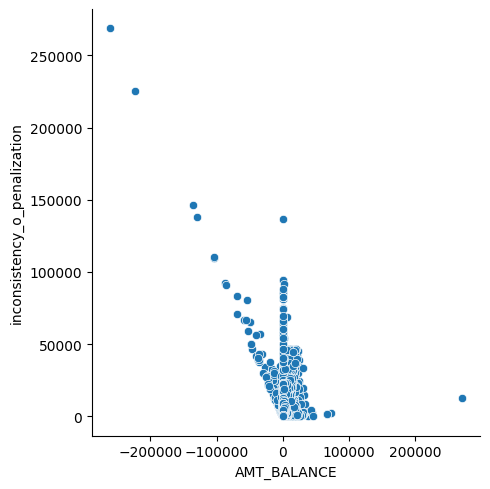

In [ ]:
credit_card_df["inconsistency_o_penalization"] = (invariant_violated_cases["AMT_INST_MIN_REGULARITY"] - invariant_violated_cases["AMT_TOTAL_RECEIVABLE"]).clip(lower=0)
cases_of_analisis= credit_card_df[credit_card_df["inconsistency_o_penalization"] > 0]
sns.relplot(data= cases_of_analisis, x="AMT_BALANCE", y= "inconsistency_o_penalization", kind="scatter")
#This leads us to several interesting conclusions: first, it reinforces the premise that AMT_BALANCE  needs its lower limit clipped at 0 to avoid artifacts. 
#Negative balance (overpayment) can lead to errors when the metrics are calculated, such as in this case where a negative AMT_TOTAL_RECEIVABLE make AMT_INST_MIN_REGULARITY 
#bigger than the field that represent the rest of the debt 
#mixing them with the cases where more money is being demanded than the total of the remaining loan